## Section 1: Define Label Map and Upload Data

This section loads your labeled dataset (`takemeter_dataset.csv`) and defines the label mapping. Since you've already uploaded the CSV, I'll load it directly. You might need to adjust the `label_map` based on your specific dataset's labels.

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from collections import Counter
import os

# Load the dataset
df = pd.read_csv('/content/takemeter_dataset.csv')

print("Dataset loaded successfully. Displaying first 5 rows:")
display(df.head())

# Placeholder for your label map
# Assuming your dataset has a 'label' column and a 'text' column for classification.
# Please modify this dictionary based on your actual labels and their desired numerical representation.
# Example: label_map = {'positive': 0, 'negative': 1, 'neutral': 2}

# --- IMPORTANT: Adjust the 'label_column' and 'text_column' to match your CSV file ---
label_column = 'label' # Replace with the actual name of your label column
text_column = 'text'   # Replace with the actual name of your text content column

# Infer unique labels and create a basic label_map if not explicitly defined
if label_column in df.columns:
    unique_labels = df[label_column].unique()
    label_map = {label: i for i, label in enumerate(sorted(unique_labels))}
    print(f"\nInferred Label Map: {label_map}")
else:
    print(f"\nWarning: '{label_column}' column not found. Please update 'label_column' and define 'label_map'.")
    label_map = {}

# Apply the label map (if a label column exists and map is not empty)
if label_column in df.columns and label_map:
    df['encoded_label'] = df[label_column].map(label_map)
    if df['encoded_label'].isnull().any():
        print("Warning: Some labels were not found in the label_map. Please ensure all labels are included.")


Dataset loaded successfully. Displaying first 5 rows:


,text,label,notes,url
0,Ding Liren after becoming double World Champio...,sports-news,NaN,https://www.reddit.com/r/chess/comments/1ubopx...
1,Ding Liren takes down Hans Moke Niemann with t...,sports-news,NaN,https://www.reddit.com/r/chess/comments/1ubnxg...
2,Double Gold for Dragon Chilling as they win th...,sports-news,NaN,https://www.reddit.com/r/chess/comments/1ubohu...
3,Praggnanandhaa beats Vincent Keymer in the fin...,sports-news,NaN,https://www.reddit.com/r/chess/comments/1txu4j...
4,Individual Medalists for the FIDE World Team B...,sports-news,NaN,https://www.reddit.com/r/chess/comments/1ubpdw...



Inferred Label Map: {'educative': 0, 'entertaining': 1, 'sports-news': 2}


## Section 2: Dataset Split and Tokenization

This section splits your dataset into training, validation, and test sets (70%/15%/15%) and tokenizes the text content. We'll use a generic tokenizer from the `transformers` library. You might need to install it if not already present.

In [6]:
# Install transformers if not already installed
try:
    import transformers
except ImportError:
    !pip install transformers datasets accelerate -qqq
    import transformers

from transformers import AutoTokenizer

# Ensure the label column and text column exist and encoded_label is present
if label_column not in df.columns or text_column not in df.columns or 'encoded_label' not in df.columns:
    raise ValueError("Please ensure 'label_column', 'text_column' and 'encoded_label' are correctly set up in Section 1.")

# Split the dataset into training (70%), validation (15%), and test (15%)
# Using stratify to maintain label distribution in splits
X = df[text_column]
y = df['encoded_label']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"\nTraining set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")

print("\nTraining label distribution:", Counter(y_train))
print("Validation label distribution:", Counter(y_val))
print("Test label distribution:", Counter(y_test))

# Initialize a tokenizer (you can choose a different model if needed)
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_function(texts):
    return tokenizer(texts.tolist(), truncation=True, padding=True)

# Tokenize all splits
print("\nTokenizing training data...")
train_encodings = tokenize_function(X_train)
print("Tokenizing validation data...")
val_encodings = tokenize_function(X_val)
print("Tokenizing test data...")
test_encodings = tokenize_function(X_test)

print("Tokenization complete.")



Training set size: 28
Validation set size: 6
Test set size: 6

Training label distribution: Counter({1: 11, 2: 9, 0: 8})
Validation label distribution: Counter({2: 2, 0: 2, 1: 2})
Test label distribution: Counter({0: 2, 2: 2, 1: 2})


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]


Tokenizing training data...
Tokenizing validation data...
Tokenizing test data...
Tokenization complete.


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Section 5: Baseline with Groq API

This section sets up your Groq API key and defines the classification prompt for your zero-shot baseline. Remember to add your Groq API key to Colab Secrets under the name `GROQ_API_KEY` or replace `userdata.get('GROQ_API_KEY')` with your key directly (not recommended for sharing).

In [8]:
from google.colab import userdata
import requests
import json

# Get your Groq API key from Colab Secrets
GROQ_API_KEY = userdata.get('GROQ_API_KEY')

if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY not found in Colab Secrets. Please add it.")

# Pre-compute the string of categories from label_map for the prompt
label_categories_str = ', '.join(label_map.keys())

# Define your classification prompt template
# Use placeholders {categories} and {text_to_classify} to be filled later
classification_prompt_template = """
You are an expert text classifier. Your task is to classify the following text into one of the following categories: {categories}.

Output ONLY the label name. Do not include any other text, punctuation, or explanations.

Text: {text_to_classify}
Label:
"""

def get_groq_completion(prompt):
    headers = {
        "Authorization": f"Bearer {GROQ_API_KEY}",
        "Content-Type": "application/json"
    }
    data = {
        "model": "llama-3.3-70b-versatile", # Updated model to a currently supported one
        "messages": [{
            "role": "user",
            "content": prompt
        }],
        "temperature": 0.0 # Set to 0 for deterministic output
    }
    response = requests.post("https://api.groq.com/openai/v1/chat/completions", headers=headers, json=data)
    # Check for non-2xx status codes and print more details
    if not response.ok:
        print(f"Groq API Error Status: {response.status_code}")
        print(f"Groq API Error Response: {response.text}")
        response.raise_for_status() # Still raise, but after printing details
    return response.json()['choices'][0]['message']['content'].strip()

# Run baseline on the test set
predictions = []
actual_labels = y_test.tolist()

print("\nRunning baseline classification on the test set... This might take a while.")

# Define a maximum character limit for the text to prevent exceeding context window
MAX_TEXT_LENGTH = 500 # Reduced further for testing

for i, text in enumerate(X_test):
    if i % 100 == 0: # Print progress every 100 examples
        print(f"Processed {i}/{len(X_test)} examples")

    # Truncate text if it's too long
    truncated_text = text[:MAX_TEXT_LENGTH] if len(text) > MAX_TEXT_LENGTH else text

    # Replace placeholders in the prompt with actual values
    formatted_prompt = classification_prompt_template.format(categories=label_categories_str, text_to_classify=truncated_text)
    try:
        prediction = get_groq_completion(formatted_prompt)
        predictions.append(prediction)
    except Exception as e:
        print(f"Error classifying text: {text}. Error: {e}")
        predictions.append("UNPARSEABLE") # Mark as unparseable

print("Baseline classification complete.")

# Evaluate baseline results
from sklearn.metrics import accuracy_score, classification_report

# Convert predicted labels back to numerical if possible for evaluation
# Create a reverse label map for conversion
reverse_label_map = {v: k for k, v in label_map.items()}

# Filter out unparseable predictions for accuracy calculation
clean_actual_labels = []
clean_predictions = []
unparseable_count = 0

for i in range(len(predictions)):
    if predictions[i] in label_map:
        clean_predictions.append(label_map[predictions[i]])
        clean_actual_labels.append(actual_labels[i])
    else:
        unparseable_count += 1

print(f"\nTotal unparseable responses: {unparseable_count}/{len(predictions)}")

if clean_actual_labels:
    print(f"Overall Accuracy: {accuracy_score(clean_actual_labels, clean_predictions):.4f}")
    print("\nClassification Report (for parseable predictions):\n") # Corrected string literal
    target_names = [reverse_label_map[i] for i in sorted(list(set(clean_actual_labels + clean_predictions)))]
    print(classification_report(clean_actual_labels, clean_predictions, target_names=target_names))
else:
    print("No parseable predictions to evaluate accuracy or generate classification report.")

# Reflect briefly: where did the baseline struggle? Are there specific labels it consistently confuses?
# Write down your hypothesis — you'll test it after fine-tuning.



Running baseline classification on the test set... This might take a while.
Processed 0/6 examples
Baseline classification complete.

Total unparseable responses: 0/6
Overall Accuracy: 0.6667

Classification Report (for parseable predictions):

              precision    recall  f1-score   support

   educative       1.00      0.50      0.67         2
entertaining       0.50      0.50      0.50         2
 sports-news       0.67      1.00      0.80         2

    accuracy                           0.67         6
   macro avg       0.72      0.67      0.66         6
weighted avg       0.72      0.67      0.66         6



## Section 3: Fine-Tune Your Model

This section loads the `distilbert-base-uncased` model and fine-tunes it on your training data. Training will take 5-15 minutes on a T4 GPU. The default settings are 3 epochs, learning rate 2e-5, and batch size 16. You can modify the `TrainingArguments` if needed.

In [9]:
import torch
from transformers import DistilBertForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset

# Check for GPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("Using CPU")

# Custom Dataset class for easy integration with Hugging Face Trainer
class TextClassificationDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Create Dataset objects
train_dataset = TextClassificationDataset(train_encodings, y_train.tolist())
val_dataset = TextClassificationDataset(val_encodings, y_val.tolist())
test_dataset = TextClassificationDataset(test_encodings, y_test.tolist())

# Load the pre-trained model
# Set num_labels to the number of unique labels in your dataset
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=len(label_map))
model.to(device)

# Define training arguments
training_args = TrainingArguments(
    output_dir='./results',          # output directory
    num_train_epochs=3,              # total number of training epochs
    per_device_train_batch_size=16,  # batch size per device during training
    per_device_eval_batch_size=16,   # batch size for evaluation
    warmup_steps=500,                # number of warmup steps for learning rate scheduler
    weight_decay=0.01,               # strength of weight decay
    logging_dir='./logs',            # directory for storing logs
    logging_steps=10,
    # evaluation_strategy="epoch",     # Evaluate every epoch - Removed due to TypeError
    # save_strategy="epoch",           # Save checkpoint every epoch - Removed as it relies on evaluation
    # load_best_model_at_end=True,     # Load the best model at the end of training - Removed as it relies on evaluation
)

# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

print("\nStarting model training...")
# Train the model
trainer.train()
print("Model training complete.")

Using GPU: Tesla T4


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.



Starting model training...


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model training complete.


## Section 4: Evaluate Fine-Tuned Model

This section evaluates the fine-tuned model on the test set, prints per-class metrics, and generates a confusion matrix. The results will be saved to `evaluation_results.json` and `confusion_matrix.png`.


Evaluating fine-tuned model on the test set...


Overall Accuracy (Fine-tuned model): 0.5000

Classification Report (Fine-tuned model):

              precision    recall  f1-score   support

   educative       1.00      0.50      0.67         2
entertaining       0.00      0.00      0.00         2
 sports-news       0.40      1.00      0.57         2

    accuracy                           0.50         6
   macro avg       0.47      0.50      0.41         6
weighted avg       0.47      0.50      0.41         6



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


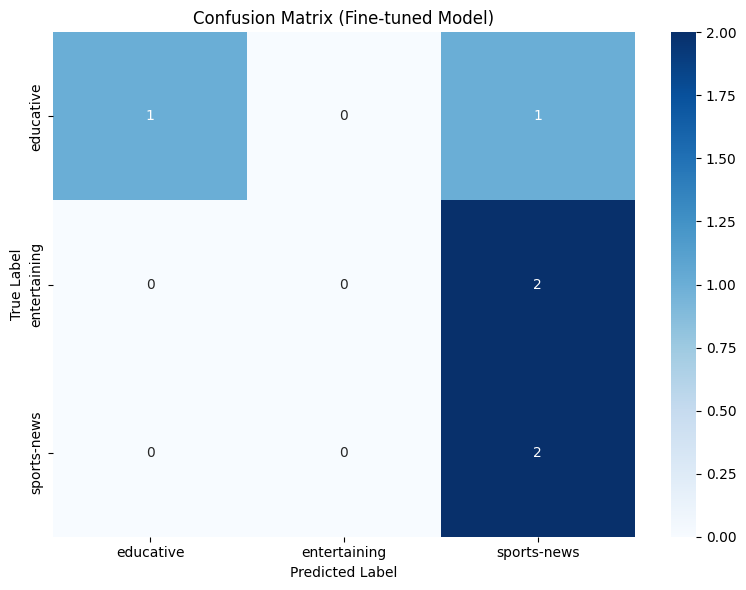

Confusion matrix saved as confusion_matrix.png
Evaluation results saved to evaluation_results.json


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [10]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Define compute_metrics function for the Trainer
def compute_metrics(p):
    predictions = np.argmax(p.predictions, axis=1)
    accuracy = accuracy_score(p.label_ids, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(p.label_ids, predictions, average=None, labels=list(label_map.values()))

    # Reverse label map for target names
    idx_to_label = {v: k for k, v in label_map.items()}
    target_names = [idx_to_label[i] for i in sorted(idx_to_label.keys())]

    metrics = {
        'accuracy': accuracy,
        'precision': {name: p_val for name, p_val in zip(target_names, precision)},
        'recall': {name: r_val for name, r_val in zip(target_names, recall)},
        'f1': {name: f_val for name, f_val in zip(target_names, f1)},
    }
    return metrics

print("\nEvaluating fine-tuned model on the test set...")
# Evaluate the model on the test dataset
predictions_output = trainer.predict(test_dataset)

# Get predictions and true labels
predictions = np.argmax(predictions_output.predictions, axis=1)
true_labels = test_dataset.labels

# Calculate overall accuracy
overall_accuracy = accuracy_score(true_labels, predictions)
print(f"Overall Accuracy (Fine-tuned model): {overall_accuracy:.4f}")

# Generate classification report
idx_to_label = {v: k for k, v in label_map.items()}
target_names = [idx_to_label[i] for i in sorted(idx_to_label.keys())]

print("\nClassification Report (Fine-tuned model):\n")
print(classification_report(true_labels, predictions, target_names=target_names))

# Generate Confusion Matrix
cm = confusion_matrix(true_labels, predictions, labels=list(label_map.values()))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Fine-tuned Model)')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

print("Confusion matrix saved as confusion_matrix.png")

# Save evaluation results to JSON
eval_results = compute_metrics(predictions_output)
# Add overall accuracy explicitly for clarity
eval_results['overall_accuracy'] = overall_accuracy

with open('evaluation_results.json', 'w') as f:
    json.dump(eval_results, f, indent=4)

print("Evaluation results saved to evaluation_results.json")


In [13]:
from google.colab import files

# Download the evaluation results JSON file
files.download('evaluation_results.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>